# NOTEBOOK: DBSCAN Clustering

 Goal: Implement and evaluate DBSCAN Clustering

## Setup

In [19]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    analyze_data
)
from src.preprocessing import DataPreprocessor
from src.models.unsupervised import SKLearnDBSCAN
from src.models.unsupervised import SKLearnPCA

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load & Explore Data

In [20]:
X = data_loader.load_customer_segmentation()

analyze_data(X, show_stats=True)

DATA ANALYSIS

Dataset shape: 200 rows × 3 columns

Data types:
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

✓ No missing values found

Numerical columns (3):
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Categorical columns (0):
[]

Numerical features statistics:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


{'numerical_cols': ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
 'categorical_cols': [],
 'missing_summary': Empty DataFrame
 Columns: [Missing_Count, Missing_Percent]
 Index: []}

## Preprocess Data

In [21]:
preprocessor = DataPreprocessor(scale=True, encode_categorical=True) # Must scale for distance-based models
X_proc = preprocessor.fit_transform(X)


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 3 columns
   Nominal categorical: 0 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 3 features

Final shape: 200 rows × 3 features



## Find Optimal eps Parameter


FINDING OPTIMAL eps FOR DBSCAN

DBSCAN Parameters:
  - eps: Maximum distance between neighbors
  - min_samples: Minimum points to form dense region

Unlike K-Means, DBSCAN DISCOVERS the number of clusters automatically
based on eps and min_samples. We don't specify k!

Strategy: Find optimal eps using silhouette score

FINDING OPTIMAL EPS FOR DBSCAN

Testing eps values: [0.1  0.15 0.2  0.25 0.3 ]...[0.75 0.8  0.85 0.9  0.95]
Using min_samples: 5

eps=0.10: 0 clusters, 200 noise
eps=0.15: 0 clusters, 200 noise
eps=0.20: 1 clusters, 195 noise
eps=0.25: 5 clusters, 165 noise, silhouette=0.6900
eps=0.30: 10 clusters, 134 noise, silhouette=0.5144
eps=0.35: 8 clusters, 110 noise, silhouette=0.4900
eps=0.40: 6 clusters, 98 noise, silhouette=0.5190
eps=0.45: 5 clusters, 75 noise, silhouette=0.5423
eps=0.50: 6 clusters, 60 noise, silhouette=0.4817
eps=0.55: 4 clusters, 39 noise, silhouette=0.2336
eps=0.60: 2 clusters, 28 noise, silhouette=0.2730
eps=0.65: 2 clusters, 21 noise, silhouette=0.264

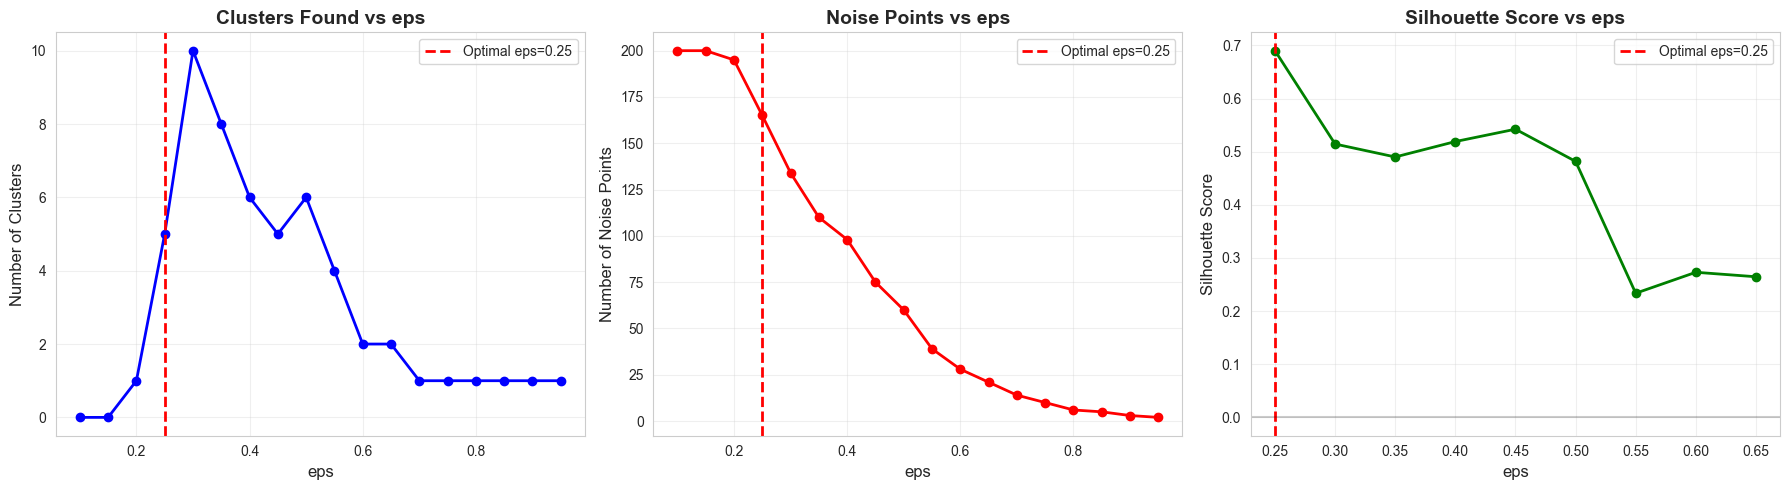


RECOMMENDED: eps=0.25
  Clusters found: 5
  Noise points: 165 (82.5%)
  Silhouette score: 0.6900


In [22]:
print("\n" + "="*70)
print("FINDING OPTIMAL eps FOR DBSCAN")
print("="*70)

print("""
DBSCAN Parameters:
  - eps: Maximum distance between neighbors
  - min_samples: Minimum points to form dense region

Unlike K-Means, DBSCAN DISCOVERS the number of clusters automatically
based on eps and min_samples. We don't specify k!

Strategy: Find optimal eps using silhouette score
""")

# Create model
model = SKLearnDBSCAN(min_samples=5)

# Find optimal eps automatically!
results = model.find_optimal_eps(
    X_proc,
    eps_range=np.arange(0.1, 1.0, 0.05),
    min_samples=5,
    show_plot=True
)

# Get recommended eps
optimal_eps = results['optimal_eps']
optimal_idx = results['eps_values'].index(optimal_eps)
optimal_n_clusters = results['n_clusters_list'][optimal_idx]
optimal_n_noise = results['n_noise_list'][optimal_idx]
optimal_silhouette = results['silhouettes'][optimal_idx]

print(f"\n{'='*70}")
print(f"RECOMMENDED: eps={optimal_eps:.2f}")
print(f"{'='*70}")
print(f"  Clusters found: {optimal_n_clusters}")
print(f"  Noise points: {optimal_n_noise} ({optimal_n_noise/len(X_proc)*100:.1f}%)")
print(f"  Silhouette score: {optimal_silhouette:.4f}")

## Train The Model With Optimal eps Parameter

In [23]:
print(f"\n{'='*70}")
print(f"RECOMMENDED: eps={optimal_eps}")
print(f"{'='*70}")

# Train final model with optimal k
print(f"\nTraining final model with eps={optimal_eps}...")
final_model = SKLearnDBSCAN(eps=optimal_eps)
final_model.fit(X_proc)

labels = final_model.predict(X_proc)

# Count clusters (excluding noise = -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"✓ DBSCAN found {n_clusters} clusters")
print(f"✓ Noise points: {n_noise} ({n_noise/len(labels)*100:.1f}%)")

print(f"\nCluster distribution:")
print(pd.Series(labels).value_counts().sort_index())


RECOMMENDED: eps=0.25000000000000006

Training final model with eps=0.25000000000000006...
✓ DBSCAN found 5 clusters
✓ Noise points: 165 (82.5%)

Cluster distribution:
-1    165
 0      6
 1      7
 2      9
 3      6
 4      7
Name: count, dtype: int64


## Cluster Evaluation

In [24]:
print("\n" + "="*70)
print("CLUSTERING METRICS")
print("="*70)

if n_clusters > 1:
    # Only calculate if we have multiple clusters
    # Exclude noise points (-1) for silhouette calculation
    mask = labels != -1
    if mask.sum() > 0:
        silhouette = final_model.silhouette_score(X_proc)
        
        print(f"Silhouette Score (excluding noise): {silhouette:.4f}")
    else:
        print("⚠️  All points classified as noise!")
else:
    print(f"⚠️  Only {n_clusters} cluster(s) found")
    print("   Try adjusting eps or min_samples")

print(f"\nNoise Detection:")
print(f"  • Noise points: {n_noise}")
print(f"  • Percentage: {n_noise/len(labels)*100:.1f}%")
print(f"  💡 Noise points can be outliers or anomalies")


CLUSTERING METRICS
Silhouette Score (excluding noise): 0.6900

Noise Detection:
  • Noise points: 165
  • Percentage: 82.5%
  💡 Noise points can be outliers or anomalies


## Dimensionality Reduction Visualization


PCA 2D VISUALIZATION

PCA: CLUSTER VISUALIZATION
Number of clusters: 5
Noise points: 165 (82.5%)
PCA explains 77.6% of variance


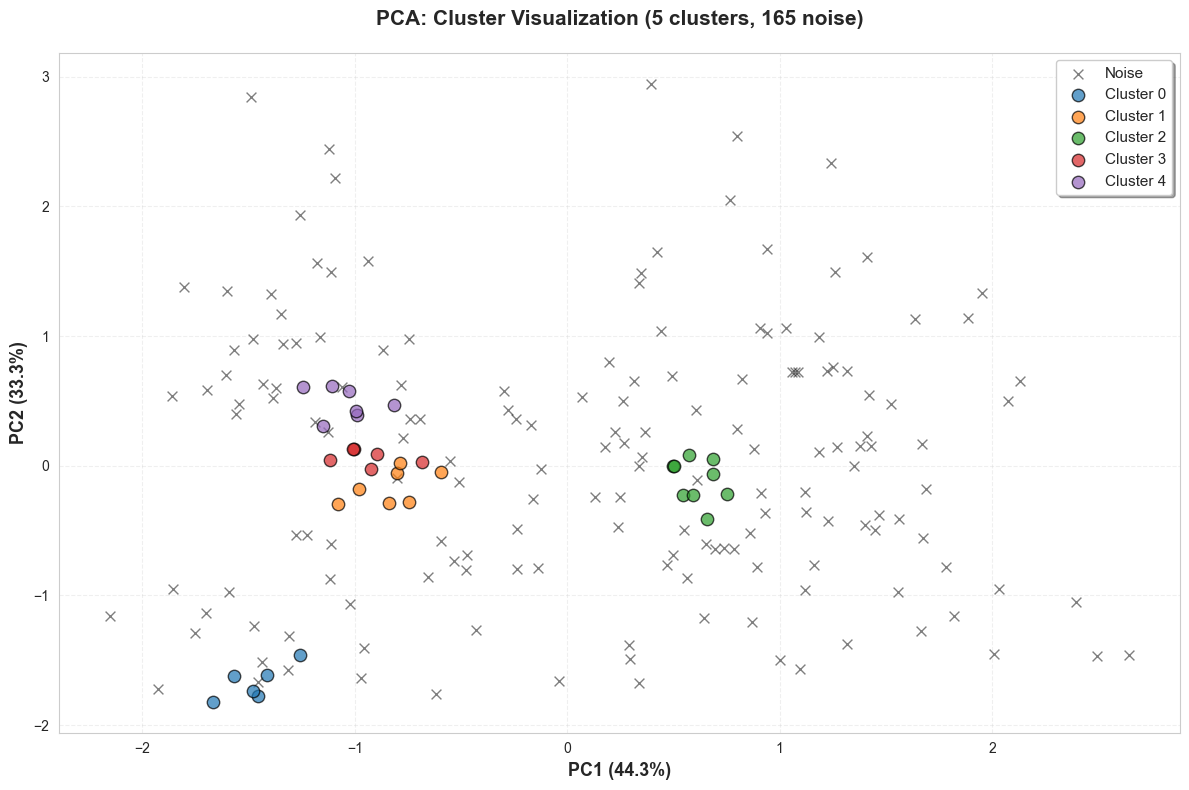


💡 Interpretation:
   • Each color = different cluster
   • Points close together = similar in feature space
   • Black X markers = noise/outliers (not assigned to any cluster)


In [25]:
print("\n" + "="*70)
print("PCA 2D VISUALIZATION")
print("="*70)

labels = final_model.predict(X_proc)
pca = SKLearnPCA(n_components=2)
pca.fit(X_proc)
pca.plot_clusters_2d(X_proc, labels)

## Silhouette Analysis


SILHOUETTE ANALYSIS
Overall Silhouette Score: 0.6900
Number of clusters: 5
ℹ️  Noise points excluded from plot


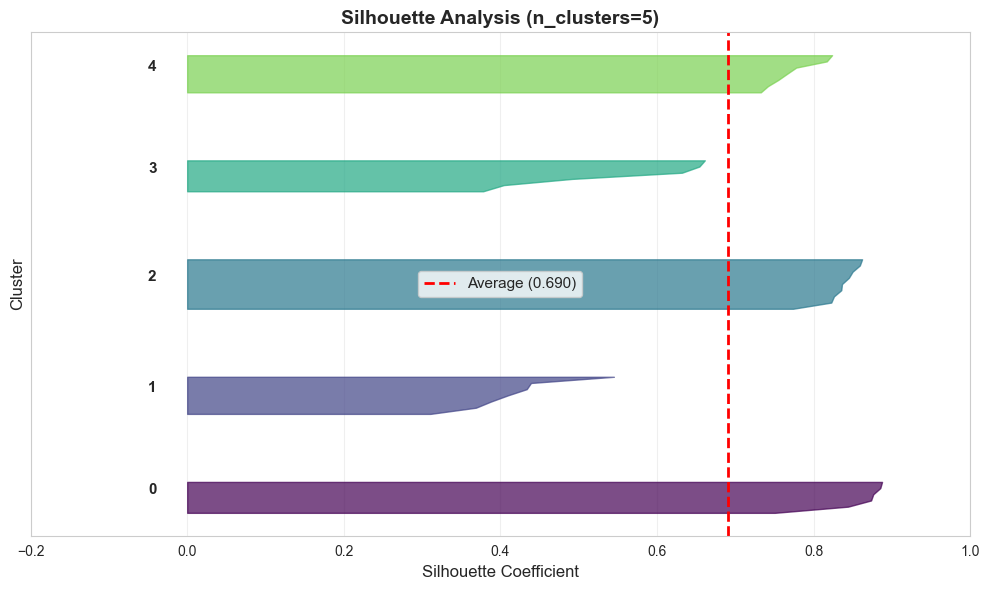


💡 How to interpret silhouette plot:
   • Width of silhouette = cluster size
   • Values > average (red line) = well-clustered samples
   • Negative values = samples likely in wrong cluster
   • Similar widths = balanced cluster sizes


In [26]:
final_model.plot_silhouette_analysis(X_proc)

## Cluster Profiling


CLUSTER PROFILES (Excluding Noise)

CLUSTER 0 (n=6)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  22.833333           18.666667               77.166667
std    1.471960            3.326660                2.714160

CLUSTER 1 (n=7)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  24.142857           57.285714               53.571429
std    2.267787            3.401680                2.370453

CLUSTER 2 (n=9)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  48.000000           56.888889               45.111111
std    1.224745            4.342938                2.713137

CLUSTER 3 (n=6)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  19.333333           63.333333               48.166667
std    1.032796            1.632993                4.020779

CLUSTER 4 (n=7)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  31.571429           74.571429               74.000000
std    1.718249            3.154739    

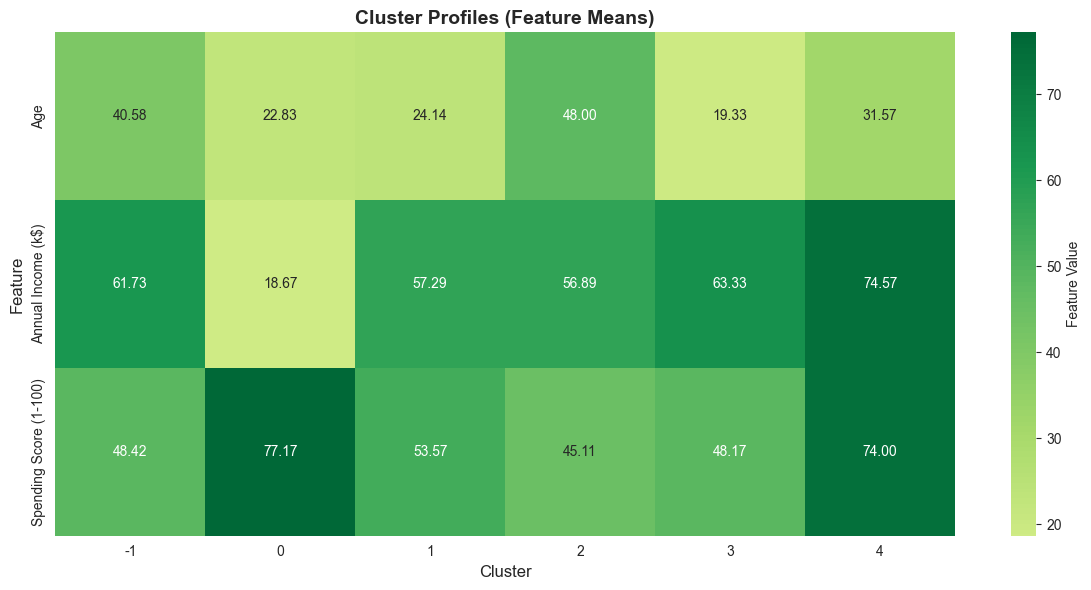


💡 Use cluster profiles to:
   • Name/interpret clusters (e.g., 'High income', 'Young users')
   • Understand what makes each cluster unique
   • Make business decisions based on cluster characteristics


In [27]:
print("\n" + "="*70)
print("CLUSTER PROFILES (Excluding Noise)")
print("="*70)

X_clustered = X.copy()
X_clustered['Cluster'] = labels

# Profile only non-noise clusters
for cluster_id in range(n_clusters):
    cluster_data = X_clustered[X_clustered['Cluster'] == cluster_id]
    
    if len(cluster_data) > 0:
        print(f"\n{'='*70}")
        print(f"CLUSTER {cluster_id} (n={len(cluster_data)})")
        print(f"{'='*70}")
        print(cluster_data.drop('Cluster', axis=1).describe().loc[['mean', 'std']])

# Profile noise points separately
noise_data = X_clustered[X_clustered['Cluster'] == -1]
if len(noise_data) > 0:
    print(f"\n{'='*70}")
    print(f"NOISE POINTS (n={len(noise_data)})")
    print(f"{'='*70}")
    print(noise_data.drop('Cluster', axis=1).describe().loc[['mean', 'std']])
    print("\n💡 These points don't fit well into any cluster")
    print("   Could be outliers, anomalies, or rare cases")

# Visualize cluster profiles
feature_cols = [col for col in X_clustered.columns if col != 'Cluster']
cluster_means = X_clustered.groupby('Cluster')[feature_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
           cbar_kws={'label': 'Feature Value'})
plt.title('Cluster Profiles (Feature Means)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\n💡 Use cluster profiles to:")
print("   • Name/interpret clusters (e.g., 'High income', 'Young users')")
print("   • Understand what makes each cluster unique")
print("   • Make business decisions based on cluster characteristics")

## Key Insights & Summary

In [28]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

print(f"\n✓ DBSCAN found {n_clusters} clusters")
print(f"✓ Noise points: {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print(f"✓ Optimal eps: {optimal_eps:.2f}")

print(f"\n💡 DBSCAN Advantages:")
print(f"   • Automatically determines number of clusters")
print(f"   • Finds arbitrarily-shaped clusters")
print(f"   • Identifies outliers as noise")
print(f"   • Robust to outliers")

print(f"\n💡 DBSCAN Limitations:")
print(f"   • Struggles with varying densities")
print(f"   • Sensitive to eps and min_samples parameters")
print(f"   • Not suitable for high-dimensional data")

print(f"\n💡 When to use DBSCAN:")
print(f"   • Handle arbitrary shapes")
print(f"   • Want automatic cluster detection")
print(f"   • Need to identify outliers")
print(f"   • Don't know K in advance")


KEY INSIGHTS

✓ DBSCAN found 5 clusters
✓ Noise points: 165 (82.5%)
✓ Optimal eps: 0.25

💡 DBSCAN Advantages:
   • Automatically determines number of clusters
   • Finds arbitrarily-shaped clusters
   • Identifies outliers as noise
   • Robust to outliers

💡 DBSCAN Limitations:
   • Struggles with varying densities
   • Sensitive to eps and min_samples parameters
   • Not suitable for high-dimensional data

💡 When to use DBSCAN:
   • Handle arbitrary shapes
   • Want automatic cluster detection
   • Need to identify outliers
   • Don't know K in advance
